## 1. The Black-Scholes Model and Analytical Solution

The Black-Scholes model is a partial differential equation (PDE) used to determine the fair price of European call options. Below is the formal derivation and its corresponding analytical and numerical representations.

### 1.1 Derivation of the Black-Scholes PDE

Consider a continuous-time portfolio $\Pi$ consisting of a long position in one European call option $C(S,t)$ and a short position of $\Delta$ shares of the underlying asset $S$:

$$\Pi = C - \Delta S$$

Over an infinitesimal time increment $dt$, the change in the portfolio's value is:

$$d\Pi = dC - \Delta dS$$

We assume that the underlying stock price follows a Geometric Brownian Motion (GBM) under the physical probability measure:

$$dS = \mu S dt + \sigma S dW_t$$

where $\mu$ is the expected physical return, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion. 

Applying **Itô's Lemma** to $C(S, t)$, the total differential $dC$ is given by:

$$dC = \left( \frac{\partial C}{\partial t} + \mu S \frac{\partial C}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} \right) dt + \sigma S \frac{\partial C}{\partial S} dW_t$$

Substituting $dS$ and $dC$ back into the portfolio differential yields:

$$d\Pi = \left( \frac{\partial C}{\partial t} + \mu S \frac{\partial C}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} - \Delta \mu S \right) dt + \sigma S \left( \frac{\partial C}{\partial S} - \Delta \right) dW_t$$

To eliminate the stochastic risk driven by $dW_t$ (making the portfolio completely risk-free), we set the hedge ratio to the option's delta:

$$\Delta = \frac{\partial C}{\partial S}$$

This simplifies the portfolio dynamic to a purely deterministic equation:

$$d\Pi = \left( \frac{\partial C}{\partial t} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} \right) dt$$

Under the assumption of a continuous, replication-based **no-arbitrage market**, a completely risk-free portfolio must yield exactly the risk-free rate of return $r$. Thus, $d\Pi = r \Pi dt$. Expanding this definition:

$$d\Pi = r (C - \Delta S) dt = r \left( C - S \frac{\partial C}{\partial S} \right) dt$$

Equating our two expressions for $d\Pi$ yields the classic **Black-Scholes PDE**:

$$\frac{\partial C}{\partial t} + r S \frac{\partial C}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} - rC = 0$$

Where:
*   $r$: The risk-free interest rate.
*   $\sigma$: The asset volatility.
*   $S$: The spot price of the underlying asset.
*   $t$: The current time coordinate ($0 \le t \le T$).

---

### 1.2 Analytical Solution (European Call Option)

For a terminal condition defined by the European call payoff at maturity $T$, given by $C(S, T) = \max(S - K, 0)$ where $K$ is the strike price, solving the PDE analytically yields:

$$C(S, t) = S \cdot N(d_1) - K e^{-r(T - t)} \cdot N(d_2)$$

Where $N(x)$ represents the standard normal cumulative distribution function (CDF), and the dimensionless parameters $d_1$ and $d_2$ are defined as:

$$d_1 = \frac{\ln\left(\frac{S}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)(T - t)}{\sigma \sqrt{T - t}}$$

$$d_2 = d_1 - \sigma \sqrt{T - t} = \frac{\ln\left(\frac{S}{K}\right) + \left(r - \frac{\sigma^2}{2}\right)(T - t)}{\sigma \sqrt{T - t}}$$



In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [3]:
# Solving Black Scholes Analytically
def BS(r, sigma, S0, K, T):
    d1 = (np.log(S0 / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    N_d1 = norm.cdf(d1, 0, 1)
    N_d2 = norm.cdf(d2, 0, 1)
    C = S0 * N_d1 - K * np.exp(-r * T)* N_d2
    return C


def plot_3d(r, sigma, K):
    time = np.linspace(0.01, 0.95, 9)
    S0_vals = np.linspace(50, 150, 50)
    S, t = np.meshgrid(S0_vals, time)
    fig, ax = plt.subplots(figsize=(11, 8), subplot_kw={"projection": "3d"})
    Z = BS(r, sigma, S, K, t)
    surf1 = ax.plot_surface(S, t, Z, cmap='viridis', edgecolor='none', label='Analytical')
    ax.view_init(elev=30, azim=-110, roll=0)
    ax.set_title("Call Option Surface")
    ax.set_xlabel("Stock Price")
    ax.set_ylabel("Time")
    ax.set_zlabel("Option Price")
    ax.legend()

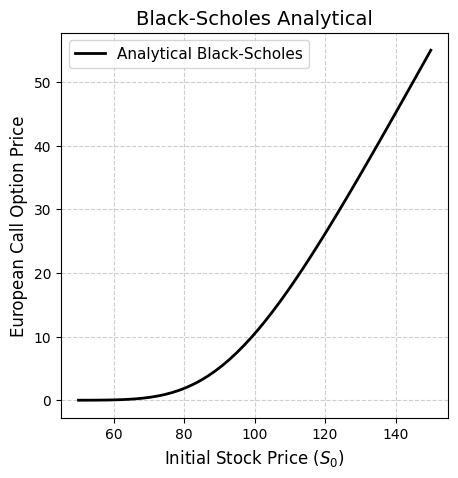

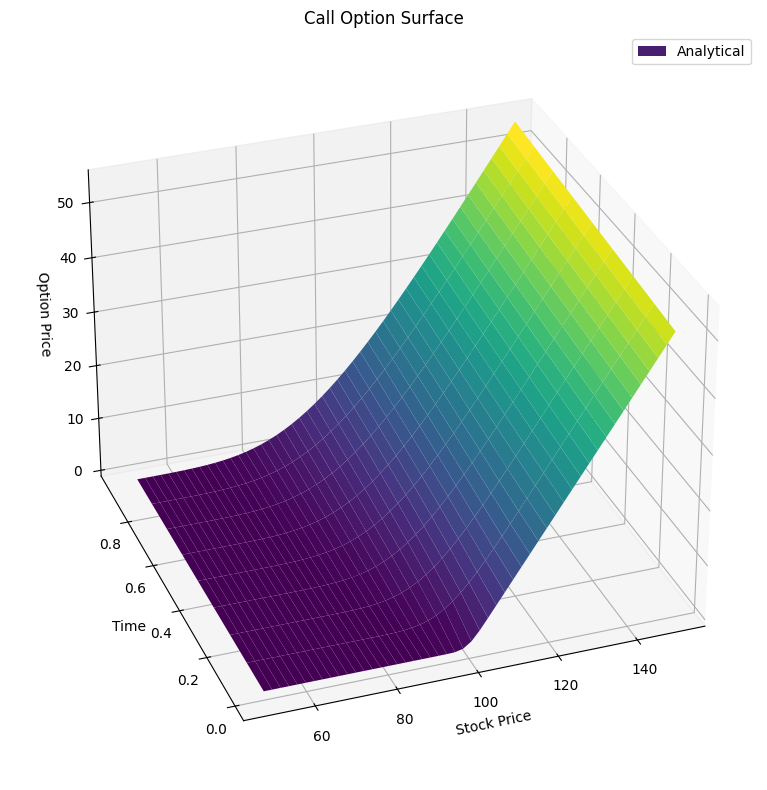

In [4]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S0_vals = np.linspace(50, 150, 50)
bs_analytical = [BS(r, sigma, s, K, T) for s in S0_vals]
# --- Plotting ---
fig, ax = plt.subplots(figsize=(5,5))

# Analytical solution curve
ax.plot(S0_vals, bs_analytical, label='Analytical Black-Scholes', color='black', linewidth=2)

ax.set_title('Black-Scholes Analytical', fontsize=14)
ax.set_xlabel('Initial Stock Price ($S_0$)', fontsize=12)
ax.set_ylabel('European Call Option Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plot_3d(r, sigma, K)
plt.tight_layout()




### 1.3 Monte Carlo Pricing Solution

Alternatively, the pricing problem can be framed via the risk-neutral pricing measure $\mathbb{Q}$. The fair option price at time $t=0$ is the discounted expected value of its terminal payoff:

$$C(S_0, 0) = e^{-rT} \mathbb{E}_\mathbb{Q} \left[ \max(S_T - K, 0) \right]$$

Under the risk-neutral probability measure $\mathbb{Q}$, the asset price dynamic substitutes the physical drift $\mu$ with the risk-free rate $r$. Integrating this stochastic differential equation gives the analytical expression for the terminal stock price $S_T$:

$$S_T = S_0 \exp\left( \left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z \right)$$

where $Z \sim \mathcal{N}(0, 1)$ is a standard normal random variable. 

By simulating $M$ independent sampling trajectories of $Z$ (denoted as $Z^{(i)}$), the continuous expectation is numerically approximated via Monte Carlo integration:

$$C(S_0, 0) \approx \frac{e^{-rT}}{M} \sum_{i=1}^{M} \max\left( S_0 \exp\left( \left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z^{(i)} \right) - K, \, 0 \right)$$

In [5]:
# Path Generation for Visualization
def generate_path(r, sigma, S0, T, num_paths, num_steps):
    Z = np.random.standard_normal()
    dt = T / num_steps
    time_grid = np.linspace(0, T, num_steps + 1)
    paths = np.zeros((num_steps + 1, num_paths))
    paths[0] = S0
    Z = np.random.standard_normal((num_steps, num_paths))
    for t in range(1, num_steps + 1):
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t-1])
        
    return time_grid, paths


# Solving Black Scholes Using Monte Carlo
def BS_MC(r, sigma, S0, K, T, num_samples):
    Z = np.random.standard_normal(num_samples)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

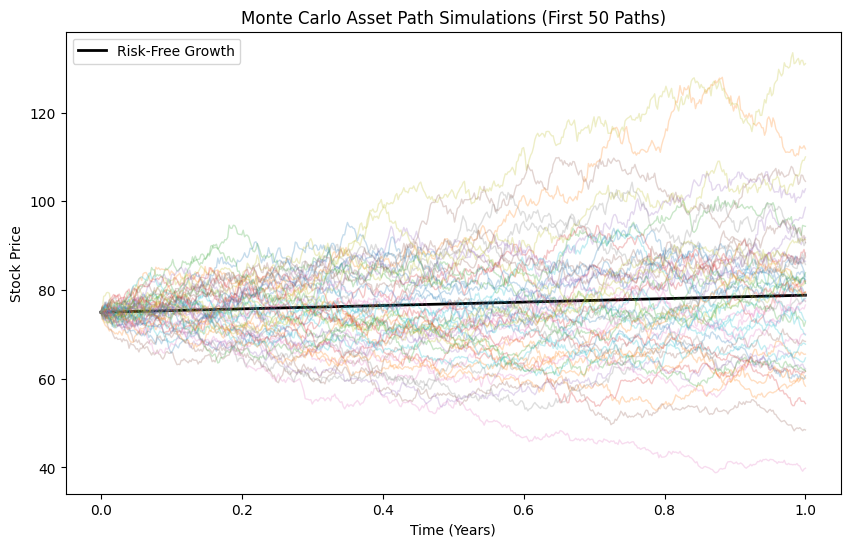

In [5]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S0 = 75        # Initial price price
time, paths = generate_path(r, sigma, S0, T, 50, 500)
risk_free_path = S0 * np.exp(time * r)
plt.figure(figsize=(10, 6))
plt.plot(time, risk_free_path, color='black', label='Risk-Free Growth', linewidth=2.0, alpha=1.0)
plt.plot(time, paths[:, :50], alpha=0.25, linewidth=1)
plt.title(f"Monte Carlo Asset Path Simulations (First 50 Paths)")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [11]:
# Range of initial stock prices to plot
S0_vals = np.linspace(50, 150, 50)
bs_analytical = [BS(r, sigma, s, K, T) for s in S0_vals]
N_low = 100
N_high = 10000
bs_mc_low = [BS_MC(r, sigma, s, K, T, N_low) for s in S0_vals]
bs_mc_high = [BS_MC(r, sigma, s, K, T, N_high) for s in S0_vals]

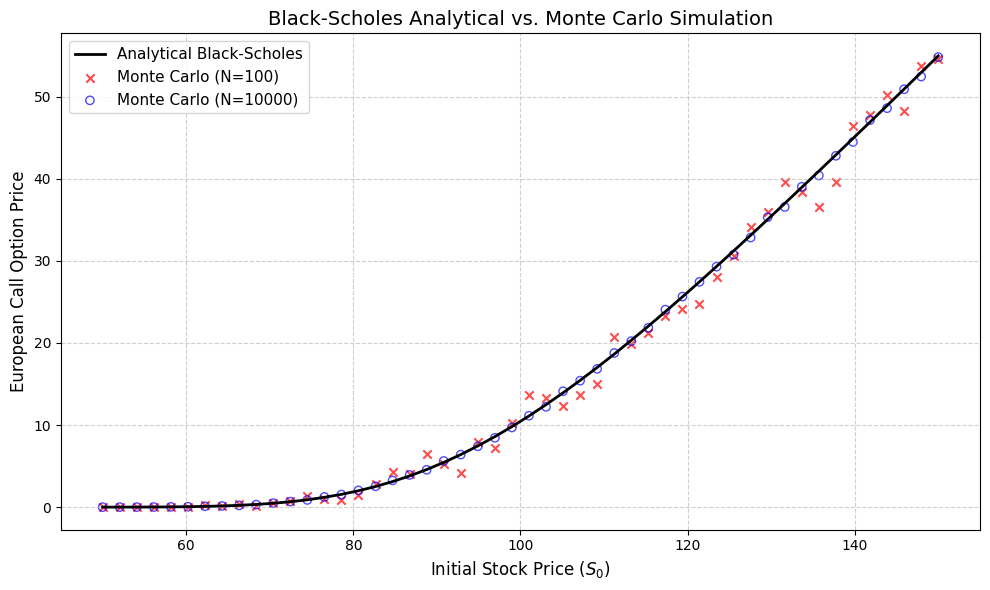

In [12]:
# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# Analytical solution curve
ax.plot(S0_vals, bs_analytical, label='Analytical Black-Scholes', color='black', linewidth=2)

# Monte Carlo with low paths 
ax.scatter(S0_vals, bs_mc_low, label=f'Monte Carlo (N={N_low})', color='red', marker='x', alpha=0.7)

# Monte Carlo with high paths 
ax.scatter(S0_vals, bs_mc_high, label=f'Monte Carlo (N={N_high})', color='blue', marker='o', 
           facecolors='none', edgecolors='blue', alpha=0.7)

ax.set_title('Black-Scholes Analytical vs. Monte Carlo Simulation', fontsize=14)
ax.set_xlabel('Initial Stock Price ($S_0$)', fontsize=12)
ax.set_ylabel('European Call Option Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()

#

## 2. Physics-Informed Neural Network (PINN) 
Another possible way to solve the Black-Scholes model is through the use of machine learning. Partial Differential Equations (PDEs) are generally hard to solve and usually require numerical methods which can be computationally expensive. One approach currently being explored is a deep learning architecture known as a Physics-Informed Neural Network (PINN). This model is used to approximate the solutions to PDEs directly without a traditional mesh.

Given a general differential equation:

$$f(\vec{x}, t) = \frac{\partial u}{\partial t} + \mathcal{D}[u(\vec{x}, t)] = 0, \quad \vec{x} \in \Omega, \quad t \in [0, T]$$
 
where $\mathcal{D}$ is a non-linear differential operator. A neural network $\hat{u}(\vec{x},t; \theta)$ is trained to approximate the target function $u(\vec{x},t)$. The partial derivatives of $\hat{u}$ are calculated exactly using **Automatic Differentiation (AD)**. The total loss function for training the PINN is defined as:

$$MSE = MSE_u + MSE_f$$

$$MSE_u = \frac{1}{N_u} \sum_{i=1}^{N_u} \left| \hat{u}(\vec{x}_i^{(u)}, t_i^{(u)}; \theta) - u_i^{(u)} \right|^2$$

$$MSE_f = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| f(\vec{x}_j^{(f)}, t_j^{(f)}; \theta) \right|^2$$

Where:
* $\hat{u}(\cdot; \theta)$ is the functional output of the neural network parameterized by weights and biases $\theta$.
* $(\vec{x}_i^{(u)}, t_i^{(u)})$ represent coordinates evaluated on the initial, terminal, or boundary constraints.
* $u_i^{(u)}$ represents the true specified value or target constraint at that point (e.g., terminal payoff).
* $f(\vec{x}_j^{(f)}, t_j^{(f)}; \theta)$ represents the residual evaluated at interior **collocation points**.

---

### References
* **Raissi et al. (2019):** *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving partial differential equations.* [Journal of Computational Physics](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125)
* **Louskos (2021):** *Physics-Informed Neural Networks for Pricing Financial Options.* [Dartmouth College Thesis](https://math.dartmouth.edu/theses/undergrad/2021/Louskos-thesis.pdf)
* **Makarov (2023):** *Applications of Physics-Informed Neural Networks in Financial Engineering.* [arXiv:2312.06711](https://arxiv.org/abs/2312.06711)


The model will be built using **PyTorch** and optimized using the built-in **Adam optimizer**.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.cuda.init()

In [19]:
# PINN model
# 2 layers and each layers has 64 neurons
# In features is S, t
class PINN_BS(nn.Module):

    def __init__(self, in_features = 2, out_features = 1, layers=3, hidden_layer=64):
        super().__init__()

        layer = [nn.Linear(in_features, hidden_layer), nn.Tanh()]
        for _ in range(layers):
            layer.append(nn.Linear(hidden_layer, hidden_layer))
            layer.append(nn.Tanh())
        layer.append(nn.Linear(hidden_layer, out_features))
        
        self.stack = nn.Sequential(*layer)
    
    def forward(self, x):
        return self.stack(x)

#### 2.1 Data and Boundary Loss ($MSE_u$)
The term $MSE_u$ enforces the boundary conditions ($S = 0$ and $S = S_{\max}$) as well as the terminal payoff condition ($t = T$). It is calculated as:

$$MSE_u = MSE_{bc1} + MSE_{bc2} + MSE_{term}$$

Where each component represents an average over its respective sampled boundary points:

* **Lower Boundary ($S = 0$):**
  $$MSE_{bc1} = \frac{1}{N_{b}} \sum_{i=1}^{N_{b}} \left| \hat{C}(0, t_i^{(b)}; \theta) - 0 \right|^2$$

* **Upper Boundary ($S = S_{\max}$):**
  $$MSE_{bc2} = \frac{1}{N_{b}} \sum_{i=1}^{N_{b}} \left| \hat{C}(S_{\max}, t_i^{(b)}; \theta) - \left( S_{\max} - K e^{-r(T - t_i^{(b)})} \right) \right|^2$$

* **Terminal Condition ($t = T$):**
  $$MSE_{term} = \frac{1}{N_{term}} \sum_{i=1}^{N_{term}} \left| \hat{C}(S_i^{(term)}, T; \theta) - \max(S_i^{(term)} - K, 0) \right|^2$$

Here, $\hat{C}$ denotes the option price predicted by the neural network, $N_{b}$ is the number of boundary evaluation points, and $N_{term}$ is the number of terminal samples.

---

#### 2.2 Residual Loss ($MSE_f$)
The term $MSE_f$ evaluates how well the network honors the underlying Black-Scholes PDE across $N_f$ collocation points randomly sampled from the interior domain $(S, t) \in (0, S_{\max}) \times (0, T)$. 

We define the interior physics residual $f(S, t)$ using automatic differentiation:

$$f(S, t) := \frac{\partial \hat{C}}{\partial t} + r S \frac{\partial \hat{C}}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 \hat{C}}{\partial S^2} - r\hat{C}$$

The interior loss is the mean squared residual across all interior points:

$$MSE_f = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| f(S_j^{(f)}, t_j^{(f)}; \theta) \right|^2$$

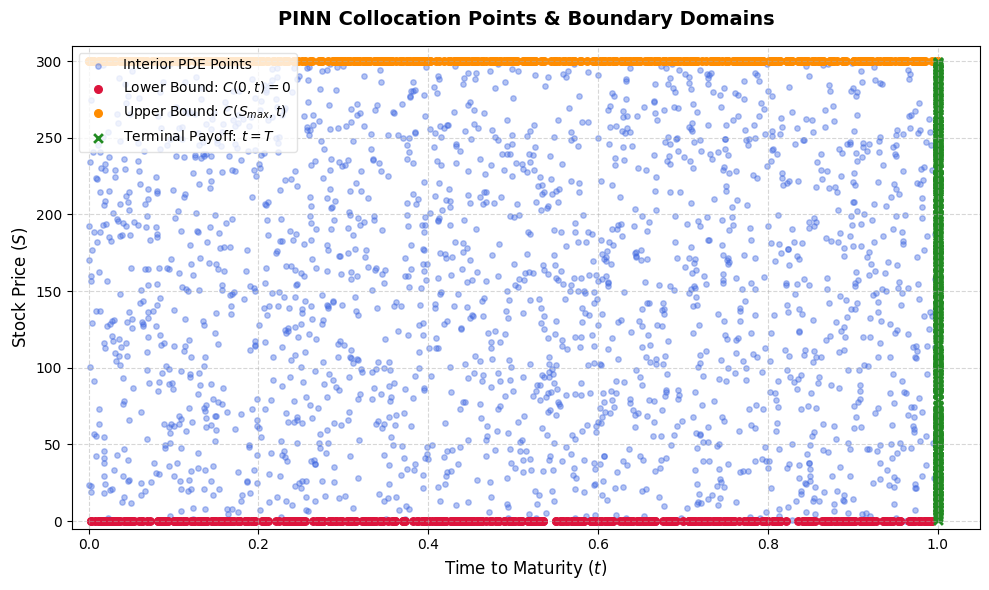

In [10]:
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K  # Upper Boundary for S -> inf

def collocation_points(S_max, T, n_pde=2000, n_boundary=500):
     # 1. Interior Domain Points (Randomly sampled PDE points)
    t_pde = (torch.rand(n_pde) * T).requires_grad_(True)
    s_pde = (torch.rand(n_pde) * S_max).requires_grad_(True)

    # 2. Lower Boundary (S = 0)
    t_low = torch.rand(n_boundary) * T
    s_low = torch.zeros(n_boundary)

    # 3. Upper Boundary (S = S_max)
    t_high = torch.rand(n_boundary) * T
    s_high = torch.ones(n_boundary) * S_max

    # 4. Terminal Payoff Boundary (t = T)
    t_term = torch.ones(n_boundary) * T
    s_term = torch.rand(n_boundary) * S_max

    s = [s_pde, s_low, s_high, s_term]
    t = [t_pde, t_low, t_high, t_term]

    return s, t

def plot_collocation():
    s, t = collocation_points(S_max, T)
    s_pde, s_low, s_high, s_term = s
    t_pde, t_low, t_high, t_term = t

    plt.figure(figsize=(10, 6))
    
    # 1. Interior Domain Points (Randomly sampled PDE points)
    plt.scatter(t_pde.detach().numpy(), s_pde.detach().numpy(), 
                color='royalblue', alpha=0.4, s=15, label='Interior PDE Points')

    # 2. Lower Boundary (S = 0)
    plt.scatter(t_low.numpy(), s_low.numpy(), 
                color='crimson', marker='o', s=30, label='Lower Bound: $C(0, t) = 0$')

    # 3. Upper Boundary (S = S_max)
    plt.scatter(t_high.numpy(), s_high.numpy(), 
                color='darkorange', marker='o', s=30, label='Upper Bound: $C(S_{max}, t)$')

    # 4. Terminal Payoff Boundary (t = T)
    plt.scatter(t_term.numpy(), s_term.numpy(), 
                color='forestgreen', marker='x', s=40, linewidths=2, label='Terminal Payoff: $t = T$')

    plt.title('PINN Collocation Points & Boundary Domains', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Time to Maturity ($t$)', fontsize=12)
    plt.ylabel('Stock Price ($S$)', fontsize=12)
    
    # Clean grid and neat layout margins
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(-0.02, T + 0.05)
    plt.ylim(-5, S_max + 10)
    
    # Move legend outside or clear from points
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='gainsboro', fontsize=10)
    plt.tight_layout()
    plt.show()

plot_collocation()

In [21]:
def compute_pinn_loss(s, t, model):
    r = 0.05       # Risk-free rate
    sigma = 0.20   # Volatility
    K = 100        # Strike price
    T = 1          # Time to maturity (1 year)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    s_pde, s_low, s_high, s_term = [x.to(device).unsqueeze(1) for x in s]
    t_pde, t_low, t_high, t_term = [x.to(device).unsqueeze(1) for x in t]
    
    # Lower Boundary Loss: V(0, t) = 0
    pred_low = model(torch.cat((s_low, t_low), dim=1))
    bc1_loss = F.mse_loss(pred_low, torch.zeros_like(pred_low))

    # Upper Boundary Loss: V(S_max, t) ≈ S_max - K * e^(-r*(T-t))
    pred_high = model(torch.cat((s_high, t_high), dim=1))
    target_high = s_high - K * torch.exp(-r * (T - t_high))
    bc2_loss = F.mse_loss(pred_high, target_high)

    # Terminal Payoff Loss: V(S, T) = max(S - K, 0)
    pred_term = model(torch.cat((s_term, t_term), dim=1))
    target_term = torch.clamp(s_term - K, min=0.0)
    terminal_loss = F.mse_loss(pred_term, target_term)

    # PDE Loss (Black-Scholes Residual)
    pred_pde = model(torch.cat((s_pde, t_pde), dim=1))
    
    dcs = torch.autograd.grad(pred_pde, s_pde, grad_outputs=torch.ones_like(pred_pde), create_graph=True)[0]
    d2cs = torch.autograd.grad(dcs, s_pde, grad_outputs=torch.ones_like(dcs), create_graph=True)[0]
    dct = torch.autograd.grad(pred_pde, t_pde, grad_outputs=torch.ones_like(pred_pde), create_graph=True)[0]

    pde_residual = r * s_pde * dcs + 1/2 * sigma ** 2 * s_pde ** 2 * d2cs - r * s_pde + dct
    pde_loss = F.mse_loss(pde_residual, torch.zeros_like(pde_residual))
    
    return [bc1_loss, bc2_loss, terminal_loss, pde_loss]

In [31]:
# Training PINN
def train_model(data, model, optimizer, epochs):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    losses = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # Compute the custom loss
        s, t = data
        loss = compute_pinn_loss(s, t, model)
        total_loss_tensor = sum(loss)
        total_loss = total_loss_tensor.item()
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Total Loss: {total_loss:.6f} | BC1 Loss: {loss[0].item():.6f} | BC2 Loss: {loss[1].item():.6f} | Terminal Loss: {loss[2].item():.6f} | ODE Loss: {loss[3].item():.6f}")

        losses.append(total_loss)

        total_loss_tensor.backward()
        optimizer.step()

    return losses

model = PINN_BS()
epochs = 5000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
data = collocation_points(S_max, T, n_pde=2000, n_boundary=500)
training_loss = train_model(data, model, optimizer, epochs)

Epoch 0 | Total Loss: 50000.484375 | BC1 Loss: 0.009285 | BC2 Loss: 40991.683594 | Terminal Loss: 8933.787109 | ODE Loss: 75.006584
Epoch 100 | Total Loss: 28529.533203 | BC1 Loss: 3208.417725 | BC2 Loss: 20669.853516 | Terminal Loss: 4575.322266 | ODE Loss: 75.938507
Epoch 200 | Total Loss: 15723.087891 | BC1 Loss: 0.211994 | BC2 Loss: 10325.366211 | Terminal Loss: 5316.663086 | ODE Loss: 80.846283
Epoch 300 | Total Loss: 13666.683594 | BC1 Loss: 21.428696 | BC2 Loss: 6398.242676 | Terminal Loss: 7118.902344 | ODE Loss: 128.109406
Epoch 400 | Total Loss: 12978.365234 | BC1 Loss: 0.015597 | BC2 Loss: 5130.474121 | Terminal Loss: 7709.438477 | ODE Loss: 138.437134
Epoch 500 | Total Loss: 12705.724609 | BC1 Loss: 0.275298 | BC2 Loss: 4008.329102 | Terminal Loss: 8402.049805 | ODE Loss: 295.070679
Epoch 600 | Total Loss: 12450.837891 | BC1 Loss: 1.493967 | BC2 Loss: 3101.729248 | Terminal Loss: 8944.385742 | ODE Loss: 403.228516
Epoch 700 | Total Loss: 12556.102539 | BC1 Loss: 0.253278 | 

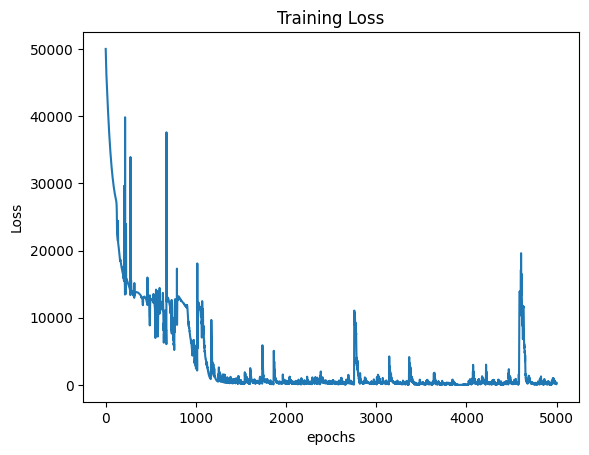

In [32]:
plt.plot(np.arange(0, epochs + 1), training_loss)
plt.ylabel("Loss")
plt.xlabel("epochs")
plt.title("Training Loss")
plt.show()

In [29]:
# Comparing PINN model solution with Monte Carlo and Analytical
def eval_model(S0_vals, time_vals, model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S0_vals = torch.from_numpy(S0_vals).float().unsqueeze(-1).to(device)
    t = torch.from_numpy(np.atleast_1d(time_vals)).float().to(device)
    t = t.repeat(S0_vals.shape[0], 1)
    x_ins = torch.cat((S0_vals, t), dim=-1)
    with torch.no_grad():
        y_pinn = model(x_ins) 
    return y_pinn.squeeze().detach().cpu().numpy()

def compare_methods(r, sigma, K, T, model):
    fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(13, 15))
    axs_flat = axs.flatten()
    time = np.linspace(0, 0.95, 9)
    S0_vals = np.linspace(50, 150, 50)
    mse_loss = 0

    for idx, t in enumerate(time):
        ax = axs_flat[idx]
        
        # Analytical
        bs_analytical = [BS(r, sigma, s, K, T) for s in S0_vals]

        # Monte Carlo
        N = 1000
        bs_mc = [BS_MC(r, sigma, s, K, T, N) for s in S0_vals]

        # PINN
        bs_pinn = eval_model(S0_vals, t, model)

        # Analytical solution curve
        ax.plot(S0_vals, bs_analytical, label='Analytical Black-Scholes', color='black', linewidth=2)

        # Monte Carlo 
        ax.scatter(S0_vals, bs_mc, label=f'Monte Carlo (N={N})', color='red', marker='x', alpha=0.7)

        # PINN solution curve
        ax.plot(S0_vals, bs_pinn, label='PINN Black-Scholes')
        
        mse_loss += (bs_analytical - bs_pinn) ** 2
        # Graph formatting
        ax.set_title(f'Option Price at $t = {t:.2f}$', fontsize=10, fontweight='bold')
        ax.set_xlabel('Initial Stock Price ($S_0$)', fontsize=10)
        ax.set_ylabel('European Call Option Price', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(fontsize=9)

    mse_loss = np.sum(mse_loss) / len(time)
    return mse_loss

Total Loss: 894.4284863749724


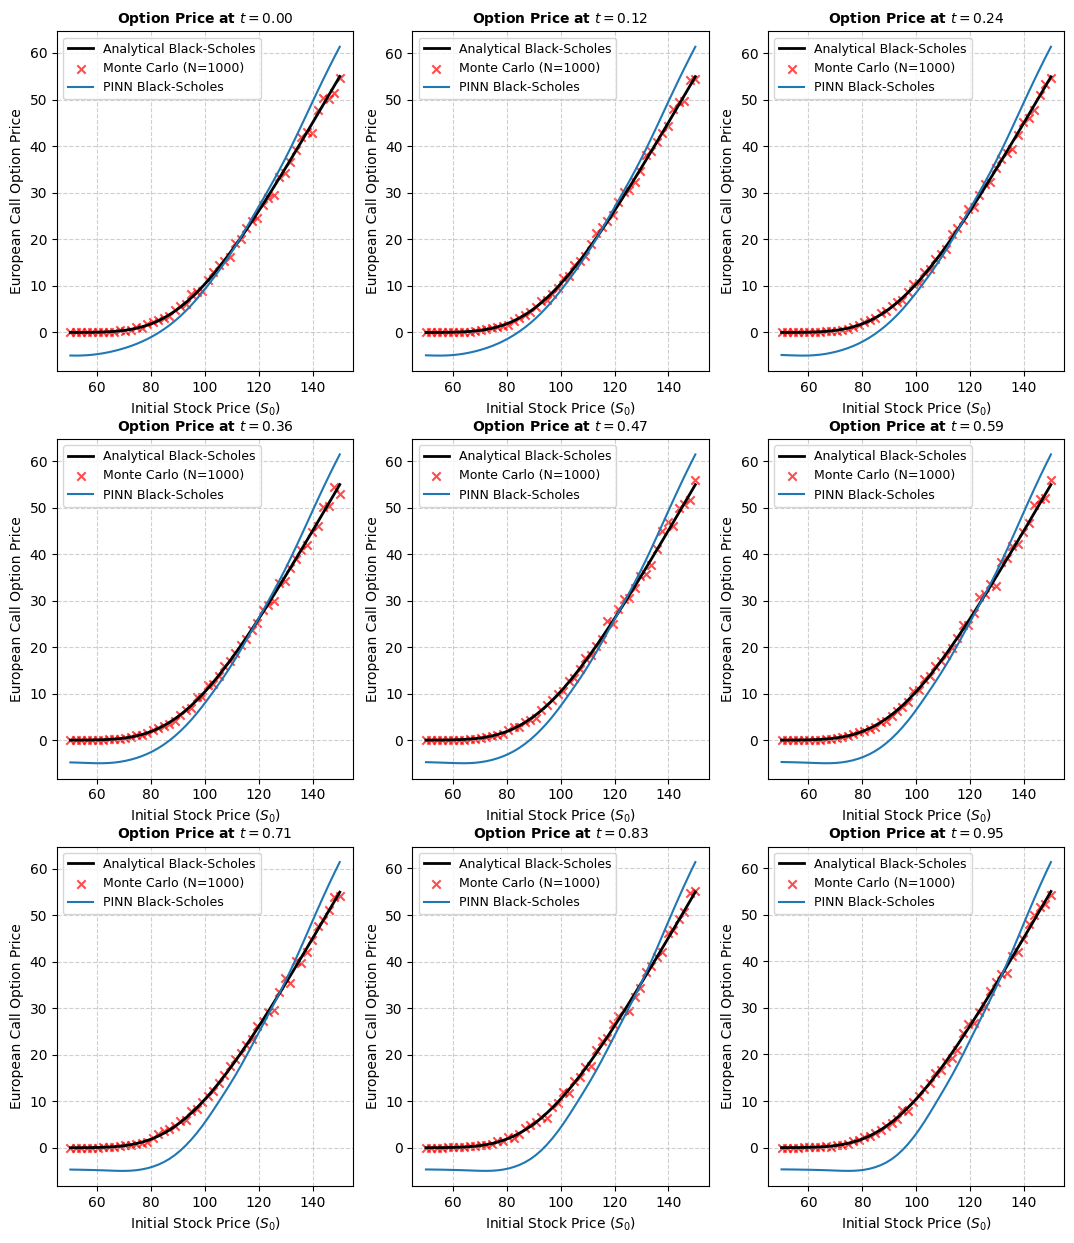

In [33]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
print(f"Total Loss: {compare_methods(r, sigma, K, T, model)}")

# 3. Optimization
One thing to notice is the PINN loss is large from the start of training, and even at the end the loss is still huge hence the estimation of black scholes is off as shown above. Some papers shown which optimizer is suitable for PINN. For optimizer tuning most uses Adam, LBFGS or combination of both Adam + LBFGS.
First order methods like SGD, AdaGrad are tested to see how badly it is.
https://arxiv.org/abs/2501.16371
https://arxiv.org/abs/2402.01868

In [34]:
from pyhessian import hessian

In [35]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
S_max = 3 * K  # Upper Boundary for S -> inf


In [36]:
model = PINN_BS()
data = collocation_points(S_max, T, n_pde=2000, n_boundary=500)
h = hessian(model, compute_pinn_loss, data, device='cuda')
eigen_list_full, weight_list_full = h.density()


In [37]:
def generate_density(eigenvalues, weights, num_grid_points=int(1e5), sigma_squared=1e-5, boundary_margin=1e-3):

  def gaussian(x, x0, variance):
    return np.exp(-(x0 - x)**2 / (2.0 * variance)) / np.sqrt(2 * np.pi * variance)

  eigenvalues = np.array(eigenvalues).real
  weights = np.array(weights).real

  num_runs, num_eigvals = eigenvalues.shape

  lambda_max = np.mean(np.max(eigenvalues, axis=1), axis=0) + boundary_margin
  lambda_min = np.mean(np.min(eigenvalues, axis=1), axis=0) - boundary_margin

  grid_points = np.linspace(lambda_min, lambda_max, num=num_grid_points)
  grid_length = (lambda_max - lambda_min) / (num_grid_points - 1)

  sigma = sigma_squared * max(1, (lambda_max - lambda_min))

  # compute density
  densities = np.zeros((num_runs, num_grid_points), dtype=eigenvalues.dtype)
  for i in range(num_runs):
    for j in range(num_grid_points):
      x = grid_points[j]
      convolutions = gaussian(eigenvalues[i,:], x, sigma)
      densities[i,j] = np.sum(convolutions * weights[i,:])

  # average across runs
  densities = np.mean(densities, axis=0)
  densities = densities / (np.sum(densities) * grid_length)

  return densities, grid_points

def get_esd_plot(eigenvalues, weights):
    density, grids = generate_density(eigenvalues, weights)
    plt.semilogy(grids, density + 1.0e-7)
    plt.ylabel('Density (Log Scale)', fontsize=14, labelpad=10)
    plt.xlabel('Eigenvlaue', fontsize=14, labelpad=10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.axis([np.min(eigenvalues) - 1, np.max(eigenvalues) + 1, None, None])
    plt.tight_layout()
    plt.savefig('example.pdf')

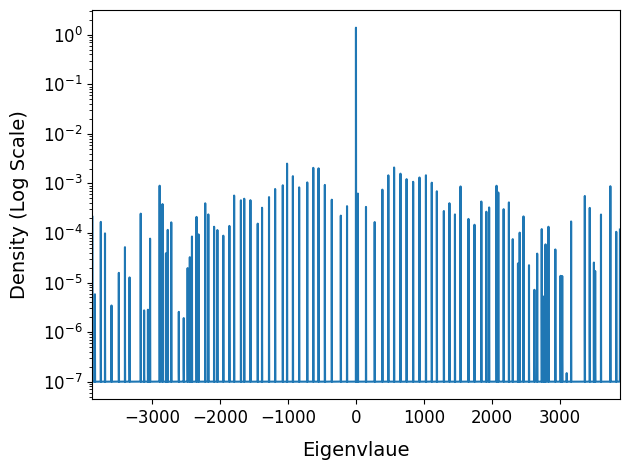

In [38]:
get_esd_plot(eigen_list_full, weight_list_full)

In [79]:
def train_model(data, model, optimizer, epochs):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    loss_history = []
    current_losses = [0.0, 0.0, 0.0, 0.0]

    for epoch in range(epochs):
        # Closure function for L-BFGS
        def closure():
            optimizer.zero_grad()
            s, t = data
            loss_components = compute_pinn_loss(s, t, model)
            
            for i in range(4):
                current_losses[i] = loss_components[i].item()
            
            total_loss_tensor = sum(loss_components)
            total_loss_tensor.backward()
            return total_loss_tensor
        
        # Step the optimizer
        if isinstance(optimizer, torch.optim.LBFGS):
            total_loss = optimizer.step(closure)
            total_loss = sum(current_losses)
        else:
            optimizer.zero_grad()
            s, t = data
            loss_components = compute_pinn_loss(s, t, model)
            for i in range(4):
                current_losses[i] = loss_components[i].item()

            total_loss_tensor = sum(loss_components)
            total_loss_tensor.backward()
            optimizer.step()
            total_loss = total_loss_tensor.item()
            
        loss_history.append(total_loss)
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1} | Total Loss: {total_loss:.6f}")
        
    return loss_history

In [84]:
num_models = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = [PINN_BS().to(device) for _ in range(num_models)]

configs = {
    "Adam": {
        "model": models[0],
        "optimizer": torch.optim.Adam(models[0].parameters(), lr=0.001),
        "epochs": 2000
    },
    "LBFGS_wolfe": {
        "model": models[1],
        "optimizer": torch.optim.LBFGS(models[1].parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe"),
        "epochs": 100
    },
    "AdaGrad": {
        "model": models[2],
        "optimizer": torch.optim.Adagrad(models[2].parameters(), lr=0.001),
        "epochs": 2000
    },
    "Adam+LBFGS" : {
        "model": models[3],
        "optimizer_LBFGS": torch.optim.LBFGS(models[3].parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe"),
        "optimizer_Adam" : torch.optim.Adam(models[3].parameters(), lr=0.001),
        "epochs_Adam": 1000,
        "epochs_LBFGS" : 50,
    }
}

In [85]:
def optim_tune():
    results = {}
    data = collocation_points(S_max, T, n_pde=2000, n_boundary=500)
    for name, cfg in configs.items():
        print(f'Training with optimizer {name}')
        if name == "Adam+LBFGS":
            model = cfg["model"]
            epochs_Adam = cfg["epochs_Adam"]
            optimizer_Adam = cfg["optimizer_Adam"]
            
            loss_adam = train_model(data, model, optimizer_Adam, epochs_Adam)
            epochs_LBFGS = cfg["epochs_LBFGS"]
            optimizer_LBFGS = cfg["optimizer_LBFGS"]
            loss_LBFGS = train_model(data, model, optimizer_LBFGS, epochs_LBFGS)

            results[name] = {
                "x": np.concatenate((np.arange(0, epochs_Adam), np.arange(epochs_Adam, epochs_Adam + epochs_LBFGS * 2, 2))),
                "y": loss_adam + loss_LBFGS
            }
        else:
            epochs = cfg["epochs"]
            model = cfg["model"]
            optimizer = cfg["optimizer"]

            loss_y = train_model(data, model, optimizer, epochs)
            
            if name == "LBFGS_wolfe":
                results[name] = {
                    "x": np.arange(0, epochs * 6, 6),
                    "y": loss_y
                }
            else:
                results[name] = {
                    "x": np.arange(epochs),
                    "y": loss_y
                }
    return results

results = optim_tune()

Training with optimizer Adam
Epoch 100 | Total Loss: 44041.429688
Epoch 200 | Total Loss: 40837.125000
Epoch 300 | Total Loss: 37815.312500
Epoch 400 | Total Loss: 34951.613281
Epoch 500 | Total Loss: 32314.496094
Epoch 600 | Total Loss: 29854.550781
Epoch 700 | Total Loss: 27567.113281
Epoch 800 | Total Loss: 25427.582031
Epoch 900 | Total Loss: 23431.302734
Epoch 1000 | Total Loss: 21577.638672
Epoch 1100 | Total Loss: 19824.421875
Epoch 1200 | Total Loss: 18192.609375
Epoch 1300 | Total Loss: 16669.226562
Epoch 1400 | Total Loss: 15248.114258
Epoch 1500 | Total Loss: 13924.150391
Epoch 1600 | Total Loss: 12699.092773
Epoch 1700 | Total Loss: 11550.687500
Epoch 1800 | Total Loss: 10486.333008
Epoch 1900 | Total Loss: 9500.531250
Epoch 2000 | Total Loss: 8588.223633
Training with optimizer LBFGS_wolfe
Epoch 100 | Total Loss: 2.673465
Training with optimizer AdaGrad
Epoch 100 | Total Loss: 47150.000000
Epoch 200 | Total Loss: 46614.410156
Epoch 300 | Total Loss: 46293.363281
Epoch 400 

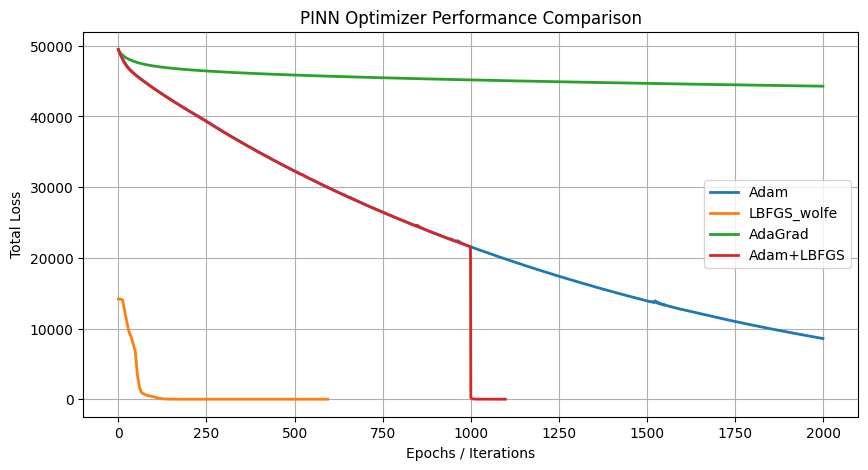

In [86]:
plt.figure(figsize=(10, 5))
for name, data in results.items():
    plt.plot(data["x"], data["y"], label=name, linewidth=2)
plt.xlabel('Epochs / Iterations')
plt.ylabel('Total Loss')
plt.title('PINN Optimizer Performance Comparison')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

In [87]:
for name, data in results.items():
    print(f'Loss ({name}): {data["y"][-1]}')

Loss (Adam): 8588.2236328125
Loss (LBFGS_wolfe): 2.6734653525054455
Loss (AdaGrad): 44285.0625
Loss (Adam+LBFGS): 3.9772602021694183


In [36]:
def weighted_loss(model, device):
    loss_components = compute_pinn_loss(model, device)
    weights = [100, 1, 1, 100]
    for i in range(len(loss_components)):
        loss_components[i] = loss_components[i] * weights[i]

    return loss_components

def train_model_weighted_loss(model, optimizer, epochs):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    losses = []
    for epoch in range(epochs + 1):
        optimizer.zero_grad()
        
        # Compute the custom loss
        loss = weighted_loss(model, device)
        total_loss_tensor = sum(loss)
        total_loss = total_loss_tensor.item()
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Total Loss: {total_loss:.6f} | BC1 Loss: {loss[0].item():.6f} | BC2 Loss: {loss[1].item():.6f} | Terminal Loss: {loss[2].item():.6f} | ODE Loss: {loss[3].item():.6f}")

        losses.append(total_loss)

        total_loss_tensor.backward()
        optimizer.step()

    return losses

Epoch 0 | Total Loss: 49856.308594 | BC1 Loss: 5.622708 | BC2 Loss: 40952.421875 | Terminal Loss: 8898.262695 | ODE Loss: 0.003555
Epoch 100 | Total Loss: 44152.972656 | BC1 Loss: 0.008830 | BC2 Loss: 36580.792969 | Terminal Loss: 7540.965332 | ODE Loss: 31.207710
Epoch 200 | Total Loss: 40936.277344 | BC1 Loss: 0.028349 | BC2 Loss: 34025.882812 | Terminal Loss: 6830.837891 | ODE Loss: 79.526291
Epoch 300 | Total Loss: 38058.214844 | BC1 Loss: 1.249771 | BC2 Loss: 31753.359375 | Terminal Loss: 6232.720215 | ODE Loss: 70.887573
Epoch 400 | Total Loss: 35101.117188 | BC1 Loss: 1.043975 | BC2 Loss: 29554.962891 | Terminal Loss: 5481.647461 | ODE Loss: 63.459187
Epoch 500 | Total Loss: 32422.236328 | BC1 Loss: 2.366156 | BC2 Loss: 27467.326172 | Terminal Loss: 4893.898926 | ODE Loss: 58.646019
Epoch 600 | Total Loss: 29954.429688 | BC1 Loss: 0.928571 | BC2 Loss: 25489.173828 | Terminal Loss: 4364.764160 | ODE Loss: 99.564445
Epoch 700 | Total Loss: 27648.484375 | BC1 Loss: 0.156173 | BC2 L

Text(0.5, 0, 'Epochs')

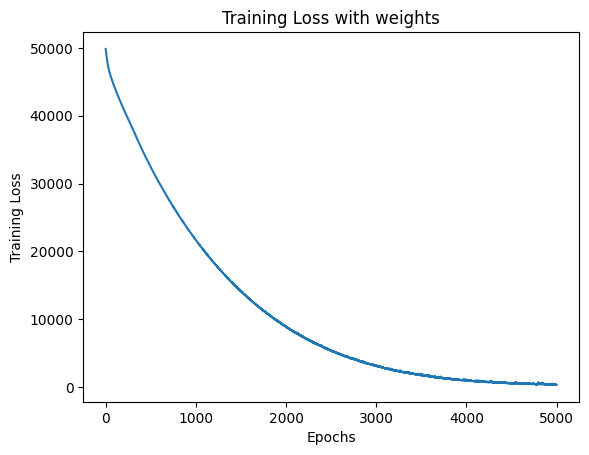

In [37]:
model_weighted_loss = PINN_BS()
optimizer = torch.optim.Adam(model_weighted_loss.parameters(), lr=0.001)
epochs = 5000

loss = train_model_weighted_loss(model_weighted_loss, optimizer, epochs)
plt.plot(np.arange(epochs + 1), loss)
plt.title("Training Loss with weights")
plt.ylabel("Training Loss")
plt.xlabel("Epochs")


TypeError: eval_model() missing 1 required positional argument: 'model'

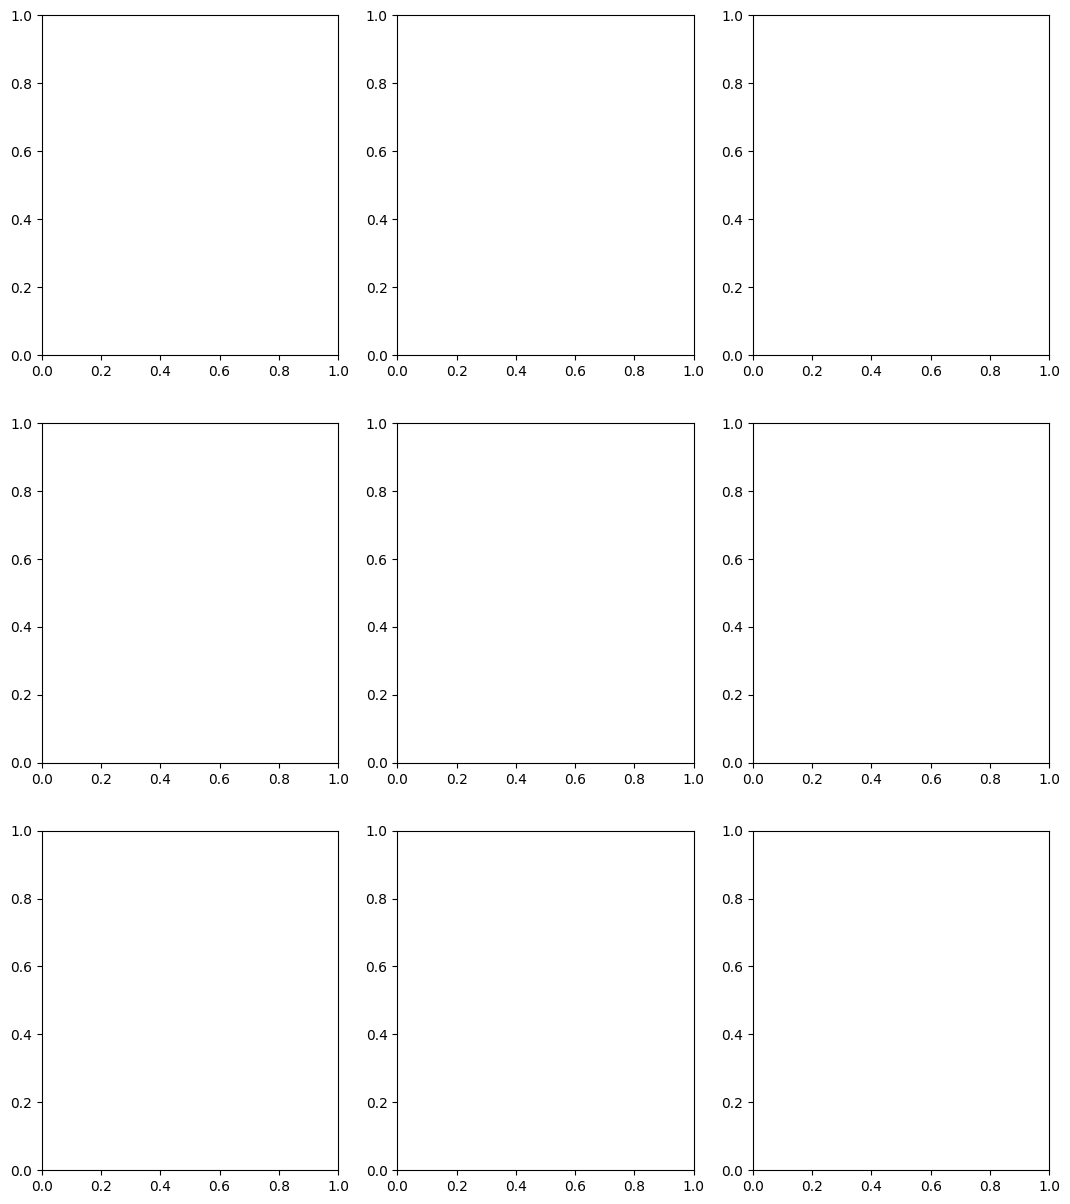

In [168]:
r = 0.05       # Risk-free rate
sigma = 0.20   # Volatility
K = 100        # Strike price
T = 1          # Time to maturity (1 year)
print(f"Total Loss: {compare_methods(r, sigma, K, T, model_weighted_loss)}")